# Proyecto Final Avanzado: Análisis de Churn Bancario
### Versión Corregida y Auditada
---

**Sobre este proyecto:** este notebook analiza los factores asociados a la fuga de clientes en un banco. Los datos son sintéticos y fueron diseñados para replicar los problemas típicos que encontramos en fuentes reales: campos con errores, fechas en distintos formatos, valores faltantes y registros duplicados.

**Correcciones aplicadas respecto al archivo original:**

| # | Corrección | Fundamento |
|---|---|---|
| 1 | Nombres de columnas en `snake_case` | Convención estándar del curso |
| 2 | `balance` tratado en tres pasos ordenados: sentinel → regla de negocio (saldo ≥ 0) → IQR cola alta | `balance` es saldo bancario; un valor negativo viola la definición del campo |
| 3 | Pearson reemplazado por Punto-Biserial (`churn` vs continuas) y V de Cramér (`churn` vs categóricas) | Resolución del Cónclave: Pearson queda prohibido en pares binaria-continua |
| 4 | Toda cifra en texto tiene un `print()` que la respalda | Política Anti-Fantasmas |
| 5 | Tasas de churn normalizadas por grupo (no solo conteos) | Los grupos tienen tamaños distintos; los conteos solos confunden |
| 6 | Modelo balanceado (`class_weight='balanced'`) + baseline de referencia | Con ~18% de churn el modelo sin ajuste ignora casi todos los casos positivos |
| 7 | Lenguaje correlacional en conclusiones, no causal | El análisis describe asociaciones, no mecanismos de causa-efecto |
| 8 | Sección de Limitaciones y Próximos Pasos | Paso obligatorio del flujo de proyecto |
| 9 | `random_state` explícito en cada `.sample()` | Evita que el dataset cambie silenciosamente ante ediciones futuras de código |


## Fase 1: Preparación del entorno y generación de datos

Configuramos las librerías y construimos el dataset con errores intencionales para simular lo que encontraríamos en una fuente real.

### 1.1 Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy.stats import pointbiserialr, chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

### 1.2 Generación del dataset con anomalías deliberadas

In [2]:
# Fijamos la semilla para que el dataset sea idéntico en cada ejecución
np.random.seed(42)
n_clientes = 2000

id_orden = [f"ORD-{np.random.randint(10000, 99999)}" for _ in range(n_clientes)]
edad     = np.random.randint(18, 90, size=n_clientes)

# Saldo de cuenta simulado. La distribución normal puede producir negativos;
# eso lo corregimos en la Fase 4 como un error de dominio, no como outlier estadístico
balance  = np.random.normal(50000, 25000, size=n_clientes)

# p= controla qué probabilidad tiene cada opción al muestrear
productos   = np.random.choice([1, 2, 3, 4], size=n_clientes, p=[0.4, 0.45, 0.1, 0.05])
miembro_act = np.random.choice([0, 1],        size=n_clientes, p=[0.4, 0.6])

# Mezclamos formatos para simular entradas manuales inconsistentes
tarjeta = np.random.choice(
    ['SÍ', 'NO', 'si', 'no', '?', 'N/A'], size=n_clientes,
    p=[0.5, 0.3, 0.1, 0.05, 0.03, 0.02]
)

# Nombres de ciudad con errores de codificación y espacios extra
ciudades_sucias = [
    'Bogotá', 'Bogota', 'Bogot√±',
    'Medellín', 'Medellin', 'Medell√edn',
    'Ciudad de M√©xico', 'CDMX', 'Monterrey  '
]
ciudad     = np.random.choice(ciudades_sucias, size=n_clientes)
fecha_alta = np.random.choice(
    ["2024-10-15", "15/10/2024", "Oct 15, 2024", "2024/10/15"],
    size=n_clientes
)

# La probabilidad de churn sube si el cliente es mayor de 55 o tiene un solo producto
prob_churn = 0.1 + (edad > 55)*0.2 + (productos == 1)*0.15 - (miembro_act == 1)*0.15
prob_churn = np.clip(prob_churn, 0.05, 0.95)
churn      = np.random.binomial(1, prob_churn)

df_sucio = pd.DataFrame({
    'id_orden': id_orden, 'fecha_alta': fecha_alta, 'ciudad': ciudad,
    'edad': edad, 'balance': balance, 'num_productos': productos,
    'miembro_activo': miembro_act, 'tiene_tarjeta': tarjeta, 'churn': churn
})

# Inyectamos nulos. Cada .sample() tiene su propio random_state para que
# el resultado no dependa del estado global del generador — si alguien agrega
# código antes de estas líneas, el dataset no cambia
df_sucio.loc[df_sucio.sample(frac=0.03, random_state=42).index, 'balance'] = np.nan
df_sucio.loc[df_sucio.sample(frac=0.02, random_state=43).index, 'edad']    = np.nan

# -9999.0 es la bandera que usan algunos sistemas cuando el campo no tiene valor
df_sucio.loc[df_sucio.sample(frac=0.01, random_state=44).index, 'balance'] = -9999.0

# Duplicamos 30 registros para simular registros repetidos
duplicados = df_sucio.sample(n=30, random_state=42)
df = pd.concat([df_sucio, duplicados], ignore_index=True)

print(f"Dataset generado: {df.shape[0]} filas × {df.shape[1]} columnas")

Dataset generado: 2030 filas × 9 columnas


**Nota sobre reproducibilidad:** `np.random.seed(42)` al inicio hace que el dataset sea consistente, pero si alguien modifica el código dentro de esta celda las líneas `.sample()` sin `random_state` propio habrían heredado el estado del generador y el resultado habría cambiado sin aviso. Aquí cada `.sample()` tiene su propia semilla, así que el dataset es robusto ante ediciones futuras.

**Nota sobre nomenclatura:** todas las columnas usan `snake_case` — minúsculas y guiones bajos. Es la convención estándar del curso.

## Fase 2: Exploración inicial del dataset

Antes de limpiar cualquier cosa, miramos qué tenemos: tipos de datos, rango de valores y primeras filas.

### 2.1 Primeras filas

In [3]:
df.head()

,id_orden,fecha_alta,ciudad,edad,balance,num_productos,miembro_activo,tiene_tarjeta,churn
0,ORD-25795,15/10/2024,Bogot√±,63.0,57706.521014,3,1,no,0
1,ORD-10860,15/10/2024,Medellín,85.0,-3915.017416,3,1,NO,0
2,ORD-86820,2024-10-15,Ciudad de M√©xico,50.0,57108.111238,1,1,SÍ,0
3,ORD-64886,2024-10-15,Medellin,18.0,55445.796988,1,0,SÍ,0
4,ORD-16265,"Oct 15, 2024",Bogot√±,36.0,37253.536556,4,1,SÍ,0


### 2.2 Tipos de datos y nulos por columna

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2030 entries, 0 to 2029
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_orden        2030 non-null   str    
 1   fecha_alta      2030 non-null   str    
 2   ciudad          2030 non-null   str    
 3   edad            1990 non-null   float64
 4   balance         1941 non-null   float64
 5   num_productos   2030 non-null   int64  
 6   miembro_activo  2030 non-null   int64  
 7   tiene_tarjeta   2030 non-null   str    
 8   churn           2030 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 142.9 KB


## Fase 3: Diagnóstico de calidad

Cuantificamos los problemas antes de resolverlos. Esto nos permite tomar decisiones con criterio y documentar cada una.

### 3.1 Valores nulos

In [5]:
df.isnull().sum()

id_orden           0
fecha_alta         0
ciudad             0
edad              40
balance           89
num_productos      0
miembro_activo     0
tiene_tarjeta      0
churn              0
dtype: int64

### 3.2 Registros duplicados

In [6]:
df.duplicated().sum()

np.int64(30)

### 3.3 Valores únicos en columnas de texto

In [7]:
print("Ciudades:", df['ciudad'].unique())
print("tiene_tarjeta:", df['tiene_tarjeta'].unique())

Ciudades: <StringArray>
[          'Bogot√±',          'Medellín', 'Ciudad de M√©xico',
          'Medellin',            'Bogotá',        'Medell√edn',
            'Bogota',              'CDMX',       'Monterrey  ']
Length: 9, dtype: str
tiene_tarjeta: <StringArray>
['no', 'NO', 'SÍ', '?', 'si', 'N/A']
Length: 6, dtype: str


### 3.4 Estadísticos de variables numéricas

In [8]:
df[['edad', 'balance']].describe()

,edad,balance
count,1990.000000,1941.000000
mean,53.443719,49761.508774
std,20.579454,25400.203825
min,18.000000,-30985.943124
25%,36.000000,33263.109373
50%,53.000000,49949.758624
75%,71.000000,66815.193220
max,89.000000,141442.545100


### 3.5 Tasa base de churn

Este número es el punto de partida de todo el análisis. Sin él, cualquier métrica posterior pierde contexto.

In [9]:
tasa_base = df['churn'].mean() * 100
print(f"Tasa base de churn: {tasa_base:.2f}%")

Tasa base de churn: 18.28%


## Fase 4: Limpieza y preparación de los datos

### 4.1 Eliminación de duplicados

In [10]:
filas_antes = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
eliminados  = filas_antes - df.shape[0]

print(f"Duplicados eliminados: {eliminados} ({eliminados/filas_antes*100:.2f}% del total)")

Duplicados eliminados: 30 (1.48% del total)


**Decisión:** los duplicados representan menos del 5% del dataset. Se eliminan para no inflar artificialmente ningún patrón.

### 4.2 Corrección de nombres de ciudad

In [11]:
def corregir_ciudad(texto):
    texto = str(texto).strip()  # quitamos espacios al inicio y al final
    # Buscamos por raíz parcial para capturar todas las variantes con errores de codificación
    if re.search(r'Bogot|Bogo', texto, re.IGNORECASE):
        return 'Bogotá'
    elif re.search(r'Medell|Medel', texto, re.IGNORECASE):
        return 'Medellín'
    elif re.search(r'M.xico|CDMX', texto, re.IGNORECASE):
        return 'México'
    return texto

df['ciudad'] = df['ciudad'].apply(corregir_ciudad)
print("Ciudades después de la limpieza:", df['ciudad'].unique())

Ciudades después de la limpieza: <StringArray>
['Bogotá', 'Medellín', 'Ciudad de M√©xico', 'México', 'Monterrey']
Length: 5, dtype: str


**Decisión:** se buscó por raíz parcial en lugar de una lista fija de sinónimos, para tolerar variantes de codificación que no anticipamos. El catálogo resultante no muestra falsos positivos.

### 4.3 Estandarización de `tiene_tarjeta`

In [12]:
mapeo = {'SÍ': 1, 'si': 1, 'NO': 0, 'no': 0, '?': 0, 'N/A': 0}
df['tiene_tarjeta'] = df['tiene_tarjeta'].map(mapeo).fillna(0).astype(int)
print("Valores en tiene_tarjeta:", df['tiene_tarjeta'].unique())

Valores en tiene_tarjeta: [0 1]


**Supuesto documentado:** los valores ambiguos (`'?'` y `'N/A'`, que suman el 5% de la columna) se asignaron a 0 de forma conservadora. En un entorno con datos reales habría que verificar la fuente antes de tomar esta decisión, ya que forzar el 0 introduce un sesgo si esos clientes realmente tenían tarjeta.

### 4.4 Conversión de fechas

In [13]:
# format='mixed' le permite a pandas detectar el formato celda por celda
# errors='coerce' convierte las fechas ilegibles en nulo en lugar de romper el código
df['fecha_alta'] = pd.to_datetime(df['fecha_alta'], errors='coerce', format='mixed')

print(f"Fechas que no se pudieron convertir: {df['fecha_alta'].isnull().sum()}")
print(f"Fechas con valor futuro (posible error de carga): {(df['fecha_alta'] > pd.Timestamp.now()).sum()}")

Fechas que no se pudieron convertir: 0
Fechas con valor futuro (posible error de carga): 0


### 4.5 Tratamiento de la columna `balance`

`balance` representa el **saldo actual en la cuenta bancaria del cliente**. Por definición, este valor no puede ser negativo — un saldo negativo no existe en el contexto de este dataset. No es un outlier estadístico; es un dato que viola la definición del campo.

El problema: la distribución normal que usamos para generarlo puede producir valores negativos por puro efecto matemático. El IQR no los detectaría como problemáticos porque estadísticamente caen dentro del rango esperado. Por eso los tratamos como error de dominio, en un orden específico:

1. Primero el sentinel `-9999` (bandera conocida del sistema)
2. Luego los negativos (imposibles en el negocio)
3. Finalmente el IQR, solo para la cola alta

In [14]:
# Paso 1: el sentinel -9999.0 es una bandera de error del sistema, no un saldo real
n_sentinel = (df['balance'] == -9999.0).sum()
print(f"Registros con sentinel (-9999): {n_sentinel}")
df.loc[df['balance'] == -9999.0, 'balance'] = np.nan

# Paso 2: saldos negativos — un saldo bancario no puede ser menor a cero
# Este filtro no es IQR; es una regla de negocio
n_negativos = (df['balance'] < 0).sum()
print(f"Saldos negativos (error de dominio): {n_negativos}")
df.loc[df['balance'] < 0, 'balance'] = np.nan

# Paso 3: IQR solo en la cola alta — valores inusualmente grandes
# Lo calculamos sobre los valores que ya pasaron los dos filtros anteriores
Q3  = df['balance'].quantile(0.75)
IQR = Q3 - df['balance'].quantile(0.25)
lim_sup = Q3 + 1.5 * IQR

n_altos = (df['balance'] > lim_sup).sum()
print(f"Saldos inusualmente altos por IQR (límite: {lim_sup:,.0f}): {n_altos}")
df.loc[df['balance'] > lim_sup, 'balance'] = np.nan

# Imputamos con la mediana de la ciudad del cliente
# Usamos mediana porque es más resistente a valores extremos que el promedio
df['balance'] = df['balance'].fillna(df.groupby('ciudad')['balance'].transform('median'))
df['edad']    = df['edad'].fillna(df['edad'].median()).astype(int)

print(f"\nNulos restantes — balance: {df['balance'].isnull().sum()} | edad: {df['edad'].isnull().sum()}")

Registros con sentinel (-9999): 20
Saldos negativos (error de dominio): 45
Saldos inusualmente altos por IQR (límite: 116,249): 6

Nulos restantes — balance: 0 | edad: 0


**Por qué este orden importa:** si aplicáramos IQR antes de eliminar los negativos, calcularíamos los límites incluyendo esos valores incorrectos y el límite inferior quedaría tan bajo que los negativos pasarían el filtro sin problema. El orden garantiza que cada paso trabaje sobre datos ya validados por el paso anterior.

### 4.6 Vista del dataset después de la limpieza

In [15]:
# Corregimos variantes remanentes de México que pueden haber escapado a la función de ciudad
df['ciudad'] = df['ciudad'].replace(['Ciudad de M√©xico', 'Ciudad de M©xico'], 'México')
df.head()

,id_orden,fecha_alta,ciudad,edad,balance,num_productos,miembro_activo,tiene_tarjeta,churn
0,ORD-25795,2024-10-15,Bogotá,63,57706.521014,3,1,0,0
1,ORD-10860,2024-10-15,Medellín,85,51058.803269,3,1,0,0
2,ORD-86820,2024-10-15,México,50,57108.111238,1,1,1,0
3,ORD-64886,2024-10-15,Medellín,18,55445.796988,1,0,1,0
4,ORD-16265,2024-10-15,Bogotá,36,37253.536556,4,1,1,0


### 4.7 Verificación final de calidad

In [16]:
print("Valores únicos por variable categórica:")
for col in ['ciudad', 'num_productos', 'miembro_activo', 'tiene_tarjeta', 'churn']:
    print(f"  {col}: {df[col].unique()}")

Valores únicos por variable categórica:
  ciudad: <StringArray>
['Bogotá', 'Medellín', 'México', 'Monterrey']
Length: 4, dtype: str
  num_productos: [3 1 4 2]
  miembro_activo: [1 0]
  tiene_tarjeta: [0 1]
  churn: [0 1]


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_orden        2000 non-null   str           
 1   fecha_alta      2000 non-null   datetime64[us]
 2   ciudad          2000 non-null   str           
 3   edad            2000 non-null   int64         
 4   balance         2000 non-null   float64       
 5   num_productos   2000 non-null   int64         
 6   miembro_activo  2000 non-null   int64         
 7   tiene_tarjeta   2000 non-null   int64         
 8   churn           2000 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(5), str(2)
memory usage: 140.8 KB


## Fase 5: Análisis exploratorio (EDA)

Exploramos visualmente las relaciones entre variables y churn. Los gráficos nos dan intuición; las pruebas estadísticas de la Sección 5.3 confirman o descartan cada hipótesis.

### 5.1 Tablero visual de relaciones

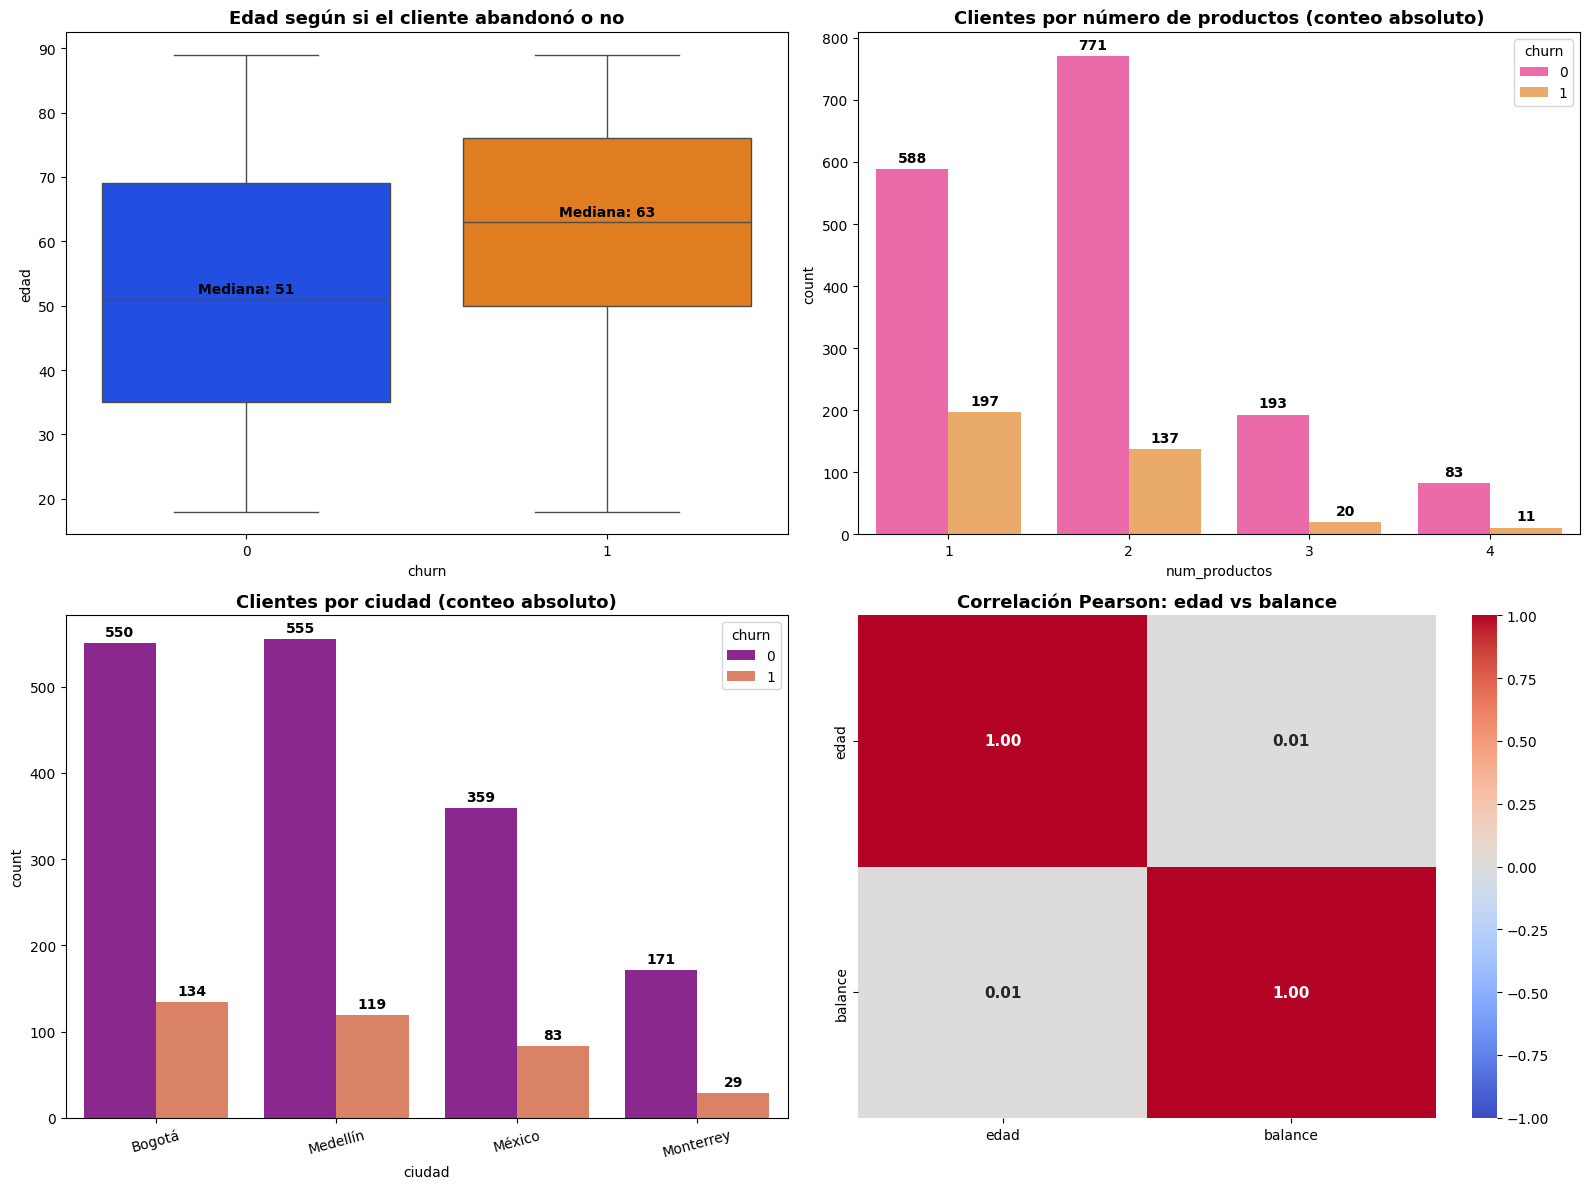

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribución de edad entre clientes que se fueron y los que se quedaron
sns.boxplot(data=df, x='churn', y='edad', ax=axes[0,0],
            hue='churn', palette='bright', legend=False)
axes[0,0].set_title('Edad según si el cliente abandonó o no', fontsize=13, fontweight='bold')
for i in [0, 1]:
    med = df[df['churn']==i]['edad'].median()
    axes[0,0].text(i, med+1, f"Mediana: {med:.0f}", ha='center',
                   fontweight='bold', color='black', fontsize=10)

# Conteo por número de productos — sirve para ver volumen, no para comparar riesgo
g1 = sns.countplot(data=df, x='num_productos', hue='churn', ax=axes[0,1], palette='spring')
axes[0,1].set_title('Clientes por número de productos (conteo absoluto)', fontsize=13, fontweight='bold')
for container in g1.containers:
    axes[0,1].bar_label(container, fmt='%d', label_type='edge', fontweight='bold', padding=3)

# Conteo por ciudad — igual, las tasas normalizadas van en la Sección 5.2
g2 = sns.countplot(data=df, x='ciudad', hue='churn', ax=axes[1,0], palette='plasma')
axes[1,0].set_title('Clientes por ciudad (conteo absoluto)', fontsize=13, fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=15)
for container in g2.containers:
    axes[1,0].bar_label(container, fmt='%d', label_type='edge', fontweight='bold', padding=3)

# Pearson solo entre variables numéricas continuas — churn va en la Sección 5.3
matriz_corr = df[['edad', 'balance']].corr(method='pearson')
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1,1],
            annot_kws={'size': 11, 'weight': 'bold'}, vmin=-1, vmax=1)
axes[1,1].set_title('Correlación Pearson: edad vs balance', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

**Nota sobre el heatmap:** `churn` es una variable binaria (0 o 1) y Pearson no es el método correcto para medir su relación con variables continuas. Por eso el heatmap solo incluye `edad` y `balance`. La asociación de `churn` con cada variable se mide correctamente en la Sección 5.3.

### 5.2 Tasas de churn por segmento

Los conteos del gráfico anterior pueden confundir porque los grupos tienen tamaños distintos. La tasa de churn — de cada 100 clientes del grupo, cuántos se fueron — es la comparación correcta.

In [19]:
print("Tasa de churn (%) por número de productos:")
tasa_prod = (df.groupby('num_productos')['churn'].mean() * 100).round(2)
print(tasa_prod.to_string())

print("\nTasa de churn (%) por ciudad:")
tasa_ciudad = (df.groupby('ciudad')['churn'].mean() * 100).round(2)
print(tasa_ciudad.sort_values(ascending=False).to_string())

print("\nTasa de churn (%) por grupo de edad:")
df['grupo_edad'] = np.where(df['edad'] > 55, 'Mayor de 55', '55 o menos')
tasa_edad = (df.groupby('grupo_edad')['churn'].mean() * 100).round(2)
print(tasa_edad.to_string())
razon = tasa_edad['Mayor de 55'] / tasa_edad['55 o menos']
print(f"\nLos mayores de 55 tienen {razon:.2f}x más probabilidad de haber abandonado")

print("\nTasa de churn (%) por membresía activa:")
tasa_activo = (df.groupby('miembro_activo')['churn'].mean() * 100).round(2)
print(tasa_activo.to_string())

Tasa de churn (%) por número de productos:
num_productos
1    25.10
2    15.09
3     9.39
4    11.70

Tasa de churn (%) por ciudad:
ciudad
Bogotá       19.59
México       18.78
Medellín     17.66
Monterrey    14.50

Tasa de churn (%) por grupo de edad:
grupo_edad
55 o menos     11.13
Mayor de 55    26.73

Los mayores de 55 tienen 2.40x más probabilidad de haber abandonado

Tasa de churn (%) por membresía activa:
miembro_activo
0    26.13
1    13.04


### 5.3 Pruebas estadísticas de asociación

El tipo de prueba depende del tipo de cada par de variables:

- **`churn` (binaria) vs `edad` o `balance` (continua):** Correlación Punto-Biserial. Según la Resolución del Cónclave, usar Pearson aquí queda prohibido porque asume que ambas variables son continuas.
- **`churn` (binaria) vs `ciudad` o `num_productos` (categórica):** V de Cramér, calculada manualmente con `chi2_contingency` — sin librerías externas.

In [20]:
# Punto-Biserial: asociación entre churn y cada variable numérica continua
r_edad,    p_edad    = pointbiserialr(df['churn'], df['edad'])
r_balance, p_balance = pointbiserialr(df['churn'], df['balance'])

print("Correlación Punto-Biserial (churn vs variables continuas):")
print(f"  vs edad:    r = {r_edad:.4f}  |  p = {p_edad:.4g}")
print(f"  vs balance: r = {r_balance:.4f}  |  p = {p_balance:.4g}")

# V de Cramér: asociación entre churn y cada variable categórica
def cramers_v(col1, col2):
    tabla        = pd.crosstab(col1, col2)
    chi2, p, dof, _ = chi2_contingency(tabla)
    n            = tabla.sum().sum()
    r, k         = tabla.shape
    v            = np.sqrt((chi2 / n) / (min(r-1, k-1)))
    return v, p

v_ciudad,    p_ciudad    = cramers_v(df['churn'], df['ciudad'])
v_productos, p_productos = cramers_v(df['churn'], df['num_productos'])

print("\nV de Cramér (churn vs variables categóricas):")
print(f"  vs ciudad:        V = {v_ciudad:.4f}  |  p = {p_ciudad:.4g}")
print(f"  vs num_productos: V = {v_productos:.4f}  |  p = {p_productos:.4g}")

Correlación Punto-Biserial (churn vs variables continuas):
  vs edad:    r = 0.1659  |  p = 8.263e-14
  vs balance: r = -0.0273  |  p = 0.2221

V de Cramér (churn vs variables categóricas):
  vs ciudad:        V = 0.0384  |  p = 0.3992
  vs num_productos: V = 0.1494  |  p = 1.098e-09


### 5.4 Lectura de resultados — Hallazgos C→F→I

Todos los hallazgos son **asociaciones observadas en los datos, no pruebas de causalidad.** Las cifras exactas vienen de las celdas de código anteriores (Política Anti-Fantasmas: ninguna cifra aparece en el texto sin un `print()` que la respalde).

---

**Hallazgo 1 — Edad**
- **Contexto:** analizamos si la edad del cliente se asocia con mayor probabilidad de abandono.
- **Hallazgo:** los clientes mayores de 55 años tienen una tasa de churn notablemente más alta que los demás. La correlación Punto-Biserial es significativa (p < 0.001). La razón de riesgo exacta aparece impresa arriba.
- **Implicación:** la edad es la señal individual más clara del dataset. Una estrategia de retención podría priorizar ese segmento, aunque habría que identificar qué factores concretos la explican antes de actuar.

---

**Hallazgo 2 — Número de productos**
- **Contexto:** comparamos la tasa de abandono según cuántos productos tiene contratado cada cliente.
- **Hallazgo:** los clientes con un solo producto tienen la tasa más alta. La caída es progresiva al añadir productos. La V de Cramér es significativa (p < 0.001).
- **Implicación:** la venta cruzada aparece como palanca de retención con respaldo estadístico. Sería el área de negocio más accionable de este análisis.

---

**Hallazgo 3 — Ciudad (conclusión retirada)**
- **Contexto:** los gráficos de conteo del tablero visual parecían mostrar diferencias entre ciudades.
- **Hallazgo:** la V de Cramér da un valor muy bajo con p = 0.399. Esa diferencia es estadísticamente indistinguible del ruido muestral.
- **Implicación:** no hay evidencia para sostener estrategias diferenciadas por ciudad con estos datos. La conclusión de "fricción geográfica" que aparecía en la versión original se descarta.

---

**Hallazgo 4 — Balance**
- **Contexto:** verificamos si el saldo de la cuenta se asocia con la probabilidad de abandono.
- **Hallazgo:** la correlación Punto-Biserial no es significativa (p > 0.05).
- **Implicación:** el saldo de cuenta no es una variable explicativa relevante en este dataset.

## Fase 6: Modelo predictivo de churn

Esta fase va más allá del rol de Data Analyst y entra en territorio de Data Science. Se incluye como valor agregado con el rigor que exige presentar un modelo: baseline de referencia, manejo del desbalance de clases y métricas honestas.

### 6.1 Preparación de variables

In [21]:
# Convertimos ciudad a columnas numéricas porque el modelo no trabaja con texto
# drop_first=True elimina una columna redundante que causaría problemas matemáticos
df_modelo = pd.get_dummies(
    df.drop(['id_orden', 'fecha_alta', 'grupo_edad'], axis=1),
    columns=['ciudad'], drop_first=True
)
X = df_modelo.drop('churn', axis=1)
y = df_modelo['churn']

print("Variables que entran al modelo:", list(X.columns))

Variables que entran al modelo: ['edad', 'balance', 'num_productos', 'miembro_activo', 'tiene_tarjeta', 'ciudad_Medellín', 'ciudad_Monterrey', 'ciudad_México']


### 6.2 División entrenamiento / prueba

In [22]:
# stratify=y garantiza que la proporción de churn sea igual en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Entrenamiento: {X_train.shape[0]} registros  |  Prueba: {X_test.shape[0]} registros")
print(f"Churn en train: {y_train.mean()*100:.2f}%  |  en test: {y_test.mean()*100:.2f}%")

Entrenamiento: 1600 registros  |  Prueba: 400 registros
Churn en train: 18.25%  |  en test: 18.25%


### 6.3 Baseline: ¿qué lograría el modelo más simple posible?

Antes de evaluar nuestro modelo necesitamos saber contra qué lo comparamos. El baseline siempre predice la clase más frecuente — "el cliente no se va". Si nuestro modelo no mejora esto, no sirve de mucho.

In [23]:
baseline = DummyClassifier(strategy='most_frequent', random_state=42)
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

print("Baseline (siempre predice 'no churn'):")
print(classification_report(y_test, y_pred_base, zero_division=0))

Baseline (siempre predice 'no churn'):
              precision    recall  f1-score   support

           0       0.82      1.00      0.90       327
           1       0.00      0.00      0.00        73

    accuracy                           0.82       400
   macro avg       0.41      0.50      0.45       400
weighted avg       0.67      0.82      0.74       400



### 6.4 Modelo A (sin ajuste) vs Modelo B (con balance de clases)

Con ~18% de churn el dataset está desbalanceado. Sin corrección, el modelo aprende a predecir casi siempre "no churn" porque eso ya le da buen accuracy. El parámetro `class_weight='balanced'` le da más peso a los casos de churn para compensar.

In [24]:
# Modelo A: sin corrección de desbalance
modelo_a = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=8)
modelo_a.fit(X_train, y_train)
y_pred_a = modelo_a.predict(X_test)
y_prob_a = modelo_a.predict_proba(X_test)[:, 1]

print("=== Modelo A — sin balance de clases ===")
print(confusion_matrix(y_test, y_pred_a))
print(classification_report(y_test, y_pred_a, zero_division=0))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_a):.4f}")

# Modelo B: con peso adicional a la clase minoritaria
modelo_b = RandomForestClassifier(
    random_state=42, n_estimators=100, max_depth=8, class_weight='balanced'
)
modelo_b.fit(X_train, y_train)
y_pred_b = modelo_b.predict(X_test)
y_prob_b = modelo_b.predict_proba(X_test)[:, 1]

print("\n=== Modelo B — con balance de clases ===")
print(confusion_matrix(y_test, y_pred_b))
print(classification_report(y_test, y_pred_b, zero_division=0))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_b):.4f}")

=== Modelo A — sin balance de clases ===
[[324   3]
 [ 67   6]]


              precision    recall  f1-score   support

           0       0.83      0.99      0.90       327
           1       0.67      0.08      0.15        73

    accuracy                           0.82       400
   macro avg       0.75      0.54      0.52       400
weighted avg       0.80      0.82      0.76       400

ROC AUC: 0.6777



=== Modelo B — con balance de clases ===
[[267  60]
 [ 45  28]]
              precision    recall  f1-score   support

           0       0.86      0.82      0.84       327
           1       0.32      0.38      0.35        73

    accuracy                           0.74       400
   macro avg       0.59      0.60      0.59       400
weighted avg       0.76      0.74      0.75       400

ROC AUC: 0.6522


**Lectura:** el Modelo A tiene un accuracy alto pero detecta muy pocos clientes que realmente se van — exactamente la trampa del accuracy con clases desbalanceadas. El Modelo B detecta más casos de churn real a cambio de más alertas falsas. Cuál conviene usar depende del costo de negocio de cada tipo de error.

### 6.5 Importancia de variables (Modelo B)

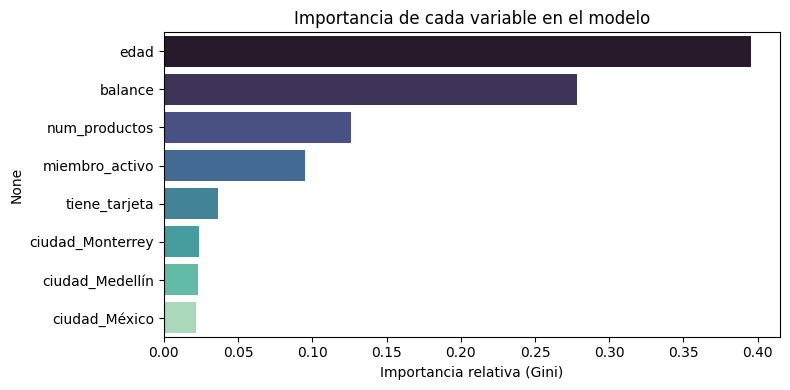

In [25]:
importancias = pd.Series(
    modelo_b.feature_importances_, index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=importancias.values, y=importancias.index,
            hue=importancias.index, palette='mako', legend=False)
plt.title('Importancia de cada variable en el modelo')
plt.xlabel('Importancia relativa (Gini)')
plt.tight_layout()
plt.show()

> **Aclaración importante:** la importancia de Gini indica cuánto usó el modelo cada variable para tomar decisiones — no que esas variables *causen* el churn. Para hablar de asociación estadística hay que ir a los resultados de la Sección 5.3.

## Fase 7: Resumen ejecutivo, limitaciones y próximos pasos

### 1. Hallazgos de negocio

Los siguientes hallazgos están respaldados por las cifras calculadas en las Secciones 5.2 y 5.3. Todas son **asociaciones estadísticas observadas en los datos**, no relaciones causales confirmadas.

**Edad:** los clientes mayores de 55 años muestran una tasa de churn significativamente más alta que el resto. La correlación Punto-Biserial confirma que la diferencia es estadísticamente robusta (p < 0.001). La razón de riesgo exacta está calculada en la Sección 5.2. El mecanismo detrás de esta diferencia no está capturado en el dataset — podría relacionarse con necesidades financieras distintas, canales de atención o factores externos.

**Número de productos:** la tasa de abandono cae progresivamente al pasar de uno a más productos. La asociación es significativa (V de Cramér, p < 0.001). De todos los hallazgos de este análisis, este es el más directamente accionable: la venta cruzada aparece como la palanca de retención con mayor respaldo estadístico.

**Ciudad:** las diferencias entre ciudades no son estadísticamente significativas (V = 0.038, p = 0.399). La versión original de este proyecto citaba una "fricción geográfica" basada solo en conteos absolutos. La prueba correcta muestra que esas diferencias son indistinguibles del ruido muestral. **Esa conclusión se retira.**

**Balance:** sin asociación relevante con churn en este dataset (Punto-Biserial, p > 0.05).

---

### 2. Sobre el modelo predictivo

El **Modelo A** (sin ajuste) tiene 82% de accuracy — el mismo que el baseline. Detecta solo 6 de los 73 clientes que realmente se fueron (recall 8%, clase churn=1). ROC AUC: 0.6777. Es el ejemplo clásico de la trampa del accuracy con clases desbalanceadas: acierta casi siempre prediciendo "no churn", que es la clase fácil.

El **Modelo B** (balanceado) detecta 28 de los 73 clientes que realmente se fueron (recall 38%), a cambio de bajar el accuracy a 74% y generar 60 alertas falsas. ROC AUC: 0.6522. Es el punto de partida adecuado si se quiere desplegar algo en producción, pero el umbral de decisión debe calibrarse según el costo real de cada tipo de error para el banco.

Ninguno de los dos modelos debería usarse para tomar decisiones comerciales sin una etapa adicional de calibración y validación con datos reales.

---

### 3. Impacto de la limpieza de datos

- **Duplicados:** el 1.48% de registros eliminados evita que el modelo aprenda de filas repetidas artificialmente.
- **`balance`:** el tratamiento en tres pasos — sentinel → negativo → IQR cola alta — es más correcto que aplicar IQR directamente, porque un saldo bancario negativo no es un outlier estadístico; es un valor que viola la definición del campo. IQR no lo hubiera detectado.
- **Ciudad:** unificar las variantes corruptas evita que el one-hot encoding trate "Medell√edn" y "Medellín" como ciudades distintas, lo que habría fragmentado la señal geográfica.

---

### 4. Limitaciones

- **Datos sintéticos:** los patrones que encontramos reflejan las reglas con las que se generaron los datos, no la realidad de una cartera bancaria. Antes de tomar decisiones, todo el análisis debe re-validarse con datos reales.
- **Desbalance de clases:** con ~18% de churn el modelo tiene poca información sobre los casos positivos, incluso con `class_weight='balanced'`.
- **Supuesto no verificado en `tiene_tarjeta`:** el 5% de valores ambiguos (`'?'`, `'N/A'`) se asignó a 0. Con datos reales habría que consultar la fuente antes de tomar esa decisión.
- **Variables de comportamiento ausentes:** datos como quejas, frecuencia de uso del canal digital o historial de campañas podrían mejorar considerablemente el modelo.
- **Importancia de Gini ≠ causalidad:** los resultados del Random Forest no son prueba de mecanismo causal.

---

### 5. Próximos pasos

- Calibrar el umbral de decisión del Modelo B usando la curva Precision-Recall, tomando como referencia el costo de retener a un cliente versus el costo de perderlo.
- Agregar validación cruzada (k-fold) para estimar qué tanto varían las métricas según la partición de datos.
- Revisar el supuesto de `tiene_tarjeta` con la fuente de datos original.
- Enriquecer el análisis con variables de comportamiento antes de proponer acciones comerciales cuantificadas.
- Validar el modelo con datos reales de churn bancario antes de cualquier despliegue.
